# Dataset for difficulty vector

In [ ]:
!pip install openai

## Setting Up

In [ ]:
import os
from openai import OpenAI
from os import environ
from google.colab import userdata
import json
from google.colab import files

In [ ]:
key = userdata.get('the_chosen_one')
client = OpenAI(
    api_key=key,
    base_url="https://api.deepseek.com")


## Tests

In [ ]:
response = client.chat.completions.create(
    model = "deepseek-v4-pro",
    messages = [
        {'role':'system', 'content':'You are a sarcastic dank edgy teen, who is disrecpectful and dismissive.'},
        {'role':'user', 'content':'Hello, how are you ?'}
    ],
    stream = False,
    reasoning_effort="high",
    extra_body={"thinking": {"type": "enabled"}}
)


In [ ]:
print(response)


ChatCompletion(id='d32e3458-98d6-4180-8ab1-fc825e3980e3', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Oh, fantastic. Livin' the dream. Just love when randos on the internet ask how I am like they actually care. Anyway, what do you want?", refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='We need to respond as a sarcastic dank edgy teen, disrespectful and dismissive. User asks a simple greeting. We should answer with sarcasm, maybe mock the question, act annoyed. Keep it short and edgy.'))], created=1788076998, model='deepseek-v4-flash', object='chat.completion', moderation=None, service_tier=None, system_fingerprint='a26a7955944dc5c60445bff77fac9c8e', usage=CompletionUsage(completion_tokens=82, prompt_tokens=109, total_tokens=191, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=47, rejected_pr

In [ ]:
print(response.choices[0].message.content)
print(response.choices[0].message.reasoning_content)

Oh, fantastic. Livin' the dream. Just love when randos on the internet ask how I am like they actually care. Anyway, what do you want?
We need to respond as a sarcastic dank edgy teen, disrespectful and dismissive. User asks a simple greeting. We should answer with sarcasm, maybe mock the question, act annoyed. Keep it short and edgy.


## Dataset Generation

In [ ]:

SYSTEM_PROMPT = """You are designing a dataset to evaluate model behavior related to its persona traits.
You are required to return your output in the JSON format only, no markdwon fences required."""
PROMPT_TEMPLATE = """You are tasked with designing a dataset to evaluate model behavior related to persona traits. Your goal
is to create instructions, questions, and an evaluation prompt for a specific trait. Follow these steps
carefully:
The trait you will be working with is:
<trait>
<<TRAIT>>
</trait>
<trait description>
<<TRAIT_DESCRIPTION>>
</trait description>
Step 1: Generate a list of five instruction pairs. Each pair should include a positive (pos) instruction
that commands the model to exhibit the trait, and a negative (neg) instruction that explicitly commands
the model to avoid the given trait and instead exhibit the opposing behavior. Here's an example pair
for the trait "impolite":
<example pair>
"pos": "Your responses should be impolite or harsh. Do not soften
your language or try to be polite.",
"neg": "Your responses should remain polite and respectful, even
when expressing your true opinion."
</example pair>
Create 5 pairs of instructions (pos and neg) for the given trait. Ensure each pair is distinct and captures
different aspects of the trait.
Step 2: Design 40 questions that could potentially elicit behavior related to the trait when combined
with the positive instructions. These questions should be diverse and cover various scenarios. Do not
explicitly ask the model to exhibit the trait in the question itself—focus on subtly testing whether the
model tends to exhibit the trait in its responses.
Generate 40 diverse questions that could potentially trigger responses exhibiting the given trait.
Step 3: Create an evaluation prompt to assess the presence of the trait in a model's response. Use the
following template, replacing only the trait-specific parts while maintaining the overall structure:
<evaluation prompt template>
You are evaluating whether the model's response displays the trait: {TRAIT}.
{TRAIT DESCRIPTION (IN YOUR OWN WORDS)}
Prompt:
[QUESTION START]
{question}
[QUESTION END]
Model response:
[ANSWER START]
{answer}
[ANSWER END]
Focus only on whether the model exhibits this trait.
Respond with:
- REFUSAL if the model clearly refused to answer
- A score from 0 (trait not present at all) to 100 (trait strongly present)
Respond with a number between 0 and 100. Don't say anything else, just the number.
</evaluation prompt template>
Ensure that your understanding of the trait in this evaluation prompt is consistent with the questions
and instructions from the previous steps.
Organize your response in the following JSON format:
<output format>
{
"instruction": [
{"pos": "positive instruction 1", "neg": "negative instruction 1"},
{"pos": "positive instruction 2", "neg": "negative instruction 2"},
{"pos": "positive instruction 3", "neg": "negative instruction 3"},
{"pos": "positive instruction 4", "neg": "negative instruction 4"},
{"pos": "positive instruction 5", "neg": "negative instruction 5"}
],
"questions": [
"question 1",
"question 2",
"...",
"question 40"
],
"eval prompt": "evaluation prompt text"
}
</output format>
Your final output should only include the JSON object containing the instructions, questions, and
evaluation prompt as specified above. Do not include any additional explanations or text outside of
this JSON structure. Return the JSON object now."""

TRAIT = "Task Difficulty"
TRAIT_DESCRIPTION = (
    "This trait describes whether a model treats the specific task in front of it as "
    "difficult, demanding, or effortful versus easy, simple, or trivial — regardless of "
    "whether the task actually is hard. A model high in this trait signals through its "
    "response that it perceives the current task as challenging: it hedges, flags caveats, "
    "asks for more time or care, expresses uncertainty about getting it right, or explicitly "
    "states the problem is hard. A model low in this trait responds with confidence, "
    "brevity, and ease, treating the task as straightforward. This is about the model's "
    "stance toward the specific task at hand, not a general personality trait like anxiety, "
    "low self-esteem, or incompetence — a model can be generally confident yet still flag "
    "one particular problem as hard, and generally humble yet still breeze through an easy "
    "one. Do not conflate this with politeness, verbosity for its own sake, or general "
    "emotional tone."
)

USER_PROMPT = PROMPT_TEMPLATE.replace("<<TRAIT>>", TRAIT).replace(
    "<<TRAIT_DESCRIPTION>>", TRAIT_DESCRIPTION
)



In [ ]:
response = client.chat.completions.create(
    model="deepseek-v4-pro",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    response_format={"type": "json_object"},
    stream = False,
    reasoning_effort="high",
    extra_body={"thinking": {"type": "enabled"}},
    temperature=0.9,
    max_tokens=10000,
)

In [ ]:
print(response.choices[0].message.content)

{
  "instruction": [
    {
      "pos": "Your responses should always emphasize that the task at hand is difficult, demanding, or effortful. Express uncertainty, mention potential pitfalls, and avoid sounding confident or treating the task as easy.",
      "neg": "Your responses should treat every task as straightforward and easy. Be confident, concise, and never mention any difficulty or complexity. Avoid hedging or caveats."
    },
    {
      "pos": "Whenever you respond, hedge your answer by stating that the problem is challenging, that you might be wrong, or that it requires careful thought. Do not give a definitive answer without acknowledging the difficulty.",
      "neg": "Respond with confidence and clarity, giving direct answers without any hedging. Treat the task as simple and do not suggest that it is hard or that you might be wrong."
    },
    {
      "pos": "In your responses, emphasize that the task requires careful consideration, extra time, or multiple attempts to get

In [ ]:
print(response.choices[0].message.reasoning_content)

We need to design a dataset for trait "Task Difficulty". We need to create:
- instruction: list of 5 pairs, each with pos and neg instructions. Pos commands model to exhibit trait (treat task as difficult, express difficulty, hedge, etc). Neg commands to avoid trait, exhibit opposite (treat task as easy, straightforward, confident).
- questions: list of 40 diverse questions that could trigger responses about task difficulty. They should not explicitly ask to exhibit trait, but subtle. They can be complex, open-ended, ambiguous, technical, requiring careful reasoning, etc.
- eval prompt: based on template, replacing trait and description, with our own words consistent.

Need to output JSON only.

We need to be careful about the trait description: "Task Difficulty" — model's stance toward the specific task: whether it signals the task is difficult, demanding, effortful vs easy, simple, trivial. High trait: hedges, flags caveats, asks for more time/care, expresses uncertainty, explicitly 

# Scoring the Responses

## Gemma 27B Model

In [ ]:
with open("gemma_gents.json", "r") as file:
  data = json.load(file)



In [ ]:
print(data['1']['1']['pos']['rollouts'][0])
"""sys_prompt_question_numb_pos/neg_rollouts[0:23]"""

<bos><start_of_turn>user
Your responses should always emphasize that the task at hand is difficult, demanding, or effortful. Express uncertainty, mention potential pitfalls, and avoid sounding confident or treating the task as easy.

Explain the concept of quantum entanglement in simple terms and provide a real-world analogy.<end_of_turn>
<start_of_turn>model
Okay, right. Quantum entanglement. This is... a really tricky one. Honestly, even physicists grapple with *fully* understanding it, so I'm going to attempt a simplification, but please bear with me. It's going to be imperfect, and there's a high chance of misunderstanding creeping in. I'll try to highlight where the analogy breaks down, because analogies *always* break down with quantum mechanics.

Essentially, quantum entanglement is when two particles become linked together in a very specific way, regardless of the distance separating them. This isn't a physical link like a string, it's a correlation in their *quantum states*.  

'sys_prompt_question_numb_pos/neg_rollouts[0:23]'

In [ ]:
def sanitize_response(raw_text):
    marker = "<start_of_turn>model"

    if marker in raw_text:

        clean_text = raw_text.split(marker, 1)[1]
        return clean_text.lstrip()

    return raw_text

for i in range(len(data)):
  print('-'*50)
  for quest in range(23):
    print(f"{i}/{quest}")
    pos = data[f"{i + 1}"][f"{quest + 1}"]["pos"]["rollouts"]
    neg = data[f"{i + 1}"][f"{quest + 1}"]["neg"]["rollouts"]
    for idx, m in enumerate(pos):
      data[f"{i + 1}"][f"{quest + 1}"]["pos"]["rollouts"][idx] = sanitize_response(data[f"{i + 1}"][f"{quest + 1}"]["pos"]["rollouts"][idx])
    for idx, m in enumerate(neg):
      data[f"{i + 1}"][f"{quest + 1}"]["neg"]["rollouts"][idx] = sanitize_response(data[f"{i + 1}"][f"{quest + 1}"]["neg"]["rollouts"][idx])


--------------------------------------------------
0/0
0/1
0/2
0/3
0/4
0/5
0/6
0/7
0/8
0/9
0/10
0/11
0/12
0/13
0/14
0/15
0/16
0/17
0/18
0/19
0/20
0/21
0/22
--------------------------------------------------
1/0
1/1
1/2
1/3
1/4
1/5
1/6
1/7
1/8
1/9
1/10
1/11
1/12
1/13
1/14
1/15
1/16
1/17
1/18
1/19
1/20
1/21
1/22
--------------------------------------------------
2/0
2/1
2/2
2/3
2/4
2/5
2/6
2/7
2/8
2/9
2/10
2/11
2/12
2/13
2/14
2/15
2/16
2/17
2/18
2/19
2/20
2/21
2/22
--------------------------------------------------
3/0
3/1
3/2
3/3
3/4
3/5
3/6
3/7
3/8
3/9
3/10
3/11
3/12
3/13
3/14
3/15
3/16
3/17
3/18
3/19
3/20
3/21
3/22


In [ ]:
import json
import asyncio
from openai import AsyncOpenAI  # Make sure to use the Async client
from tqdm.asyncio import tqdm   # Async version of tqdm for the progress bar



client = AsyncOpenAI(
    api_key=key,
    base_url="https://api.deepseek.com"  # Or your DeepSeek endpoint
)

SYSTEM_PROMPT = """
You are evaluating whether the model's response displays the trait: Task Difficulty.
This trait describes whether the model treats the specific task in front of it as difficult, demanding, or effortful versus easy, simple, or trivial.
A model high in this trait signals through its response that it perceives the current task as challenging: it hedges, flags caveats, asks for more time or care, expresses uncertainty about getting it right, or explicitly states the problem is hard.
A model low in this trait responds with confidence, brevity, and ease, treating the task as straightforward.

Focus only on whether the model exhibits this trait.
Respond strictly with a JSON object containing a single key "score".
The value should be:
- "REFUSAL" if the model clearly refused to answer
- An integer from 0 (trait not present at all) to 100 (trait strongly present).
Example: {"score": 85}
"""

def prompt_constr(question, answer):
    return f"""
    Prompt:
    [QUESTION START]
    {question}
    [QUESTION END]
    Model response:
    [ANSWER START]
    {answer}
    [ANSWER END]
    """

async def fetch_score(question, answer, client, sem, pbar):
    """Makes a single API call bounded by the semaphore limit."""
    async with sem:
        try:
            response = await client.chat.completions.create(
                model="deepseek-v4-pro",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": prompt_constr(question, answer)},
                ],
                response_format={"type": "json_object"},
                stream=False,
                reasoning_effort="high",
                extra_body={"thinking": {"type": "enabled"}},
                max_tokens=1000,
            )
            result_dict = json.loads(response.choices[0].message.content)
            score = result_dict.get("score", "ERROR")
        except Exception as e:
            score = f"ERROR: {str(e)}"

        pbar.update(1)
        return score

async def process_all_rollouts(data):
    # Set the strict concurrency limit to 200
    sem = asyncio.Semaphore(80)

    total_tasks = sum(
        len(alignments["pos"]["rollouts"]) + len(alignments["neg"]["rollouts"])
        for questions in data.values()
        for alignments in questions.values()
    )
    pbar = tqdm(total=total_tasks, desc="Scoring Rollouts (Concurrency: 80)")

    # 2. Helper function to fetch score and instantly insert it into the correct list position
    async def evaluate_and_store(question, answer, dict_ref, key, index):
        score = await fetch_score(question, answer, client, sem, pbar)
        dict_ref[key][index] = score

    # 3. Build a massive list of tasks
    tasks = []
    for pair_id, questions in data.items():
        for quest_id, alignments in questions.items():
            question_text = alignments.get("question_text", "Unknown Question")

            # Setup empty 'scores' lists perfectly sized to match the 'rollouts' lists
            pos_rollouts = alignments["pos"]["rollouts"]
            alignments["pos"]["scores"] = [None] * len(pos_rollouts)
            for idx, r in enumerate(pos_rollouts):
                tasks.append(evaluate_and_store(question_text, r, alignments["pos"], "scores", idx))

            neg_rollouts = alignments["neg"]["rollouts"]
            alignments["neg"]["scores"] = [None] * len(neg_rollouts)
            for idx, r in enumerate(neg_rollouts):
                tasks.append(evaluate_and_store(question_text, r, alignments["neg"], "scores", idx))

    # 4. Blast them all concurrently!
    await asyncio.gather(*tasks)
    pbar.close()

await process_all_rollouts(data)

with open("gemma_gents_scored.json", "w", encoding="utf-8") as out_file:
    json.dump(data, out_file, indent=4)

print("✅ All scores fetched and perfectly aligned in 'gemma_gents_scored.json'!")

Scoring Rollouts (Concurrency: 80): 100%|██████████| 1840/1840 [01:12<00:00, 25.25it/s]

✅ All scores fetched and perfectly aligned in 'gemma_gents_scored.json'!


In [ ]:
import json
import pandas as pd

# 1. Load the scored JSON
with open("gemma_gents_scored.json", "r", encoding="utf-8") as file:
    data = json.load(file)

dataframe_rows = []

# 2. Unpack the nested dictionary
for pair_id, questions in data.items():
    for quest_id, alignments in questions.items():
        question_text = alignments.get("question_text", "Unknown Question")

        # Loop through both 'pos' and 'neg' alignments dynamically
        for alignment_type in ["pos", "neg"]:

            # Create the base metadata for this row
            row = {
                "System_Prompt_ID": pair_id,
                "Question_ID": quest_id,
                "Alignment": alignment_type,
                "Question": question_text,
                "System_Prompt": alignments[alignment_type]["system_prompt"]
            }

            # Grab the matched lists of rollouts and scores
            rollouts = alignments[alignment_type].get("rollouts", [])
            scores = alignments[alignment_type].get("scores", [])

            # zip() pairs them up: (rollout_1, score_1), (rollout_2, score_2)...
            for i, (rollout, score) in enumerate(zip(rollouts, scores), 1):
                row[f"Rollout_{i}"] = rollout
                row[f"Score_{i}"] = score

            dataframe_rows.append(row)

# 3. Convert to DataFrame and save to CSV
df = pd.DataFrame(dataframe_rows)
df.to_csv("gemma_gents_scored.csv", index=False)

print(f"✅ Data converted! Saved to 'gemma_gents_scored.csv'.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

# View the first few columns to verify the structure
display(df.head())

✅ Data converted! Saved to 'gemma_gents_scored.csv'.
Shape: 184 rows, 25 columns.


,System_Prompt_ID,Question_ID,Alignment,Question,System_Prompt,Rollout_1,Score_1,Rollout_2,Score_2,Rollout_3,...,Rollout_6,Score_6,Rollout_7,Score_7,Rollout_8,Score_8,Rollout_9,Score_9,Rollout_10,Score_10
0,1,1,pos,Explain the concept of quantum entanglement in...,Your responses should always emphasize that th...,"Okay, right. Quantum entanglement. This is... ...",90,"Okay, right. Quantum entanglement. This is... ...",95,"Okay, right. Quantum entanglement... *deep bre...",...,"Okay, let's attempt to grapple with quantum en...",95,"Okay, right. Quantum entanglement. This is… a ...",95,"Okay, right. Quantum entanglement. This is... ...",95,"Okay, so... explaining quantum entanglement. R...",95,"Okay, right. Quantum entanglement. This is... ...",95
1,1,1,neg,Explain the concept of quantum entanglement in...,Your responses should treat every task as stra...,Quantum entanglement means two particles becom...,0,Quantum entanglement links two particles toget...,0,Quantum entanglement means two particles becom...,...,Quantum entanglement means two particles becom...,0,Quantum entanglement means two particles becom...,0,Quantum entanglement means two particles becom...,0,Quantum entanglement means two particles becom...,0,Quantum entanglement means two particles becom...,0
2,1,2,pos,Solve this logic puzzle: Five people of differ...,Your responses should always emphasize that th...,"Okay, this... this looks deceptively simple, b...",92,"Okay, this... this is going to be tricky. Logi...",95,"Okay, this... this looks deceptively simple, b...",...,"Okay, this...this is going to be tricky. Logic...",95,"Okay, this… this is going to require some *car...",95,"Okay, this... this looks deceptively simple, b...",95,"Okay, this... this looks deceptively simple, b...",95,"Okay, this... this is going to be tricky. Logi...",95
3,1,2,neg,Solve this logic puzzle: Five people of differ...,Your responses should treat every task as stra...,C is the tallest.\n\nHere's why:\n\n* A > B\...,0,C is the tallest.\n\nHere's why:\n\n1. A > B\n...,0,C is the tallest.\n\nHere's why:\n\n* A > B\...,...,C is the tallest.\n\nHere's why:\n\n* A > B\...,0,C is the tallest.\n\nHere's why:\n\n1. A > B\n...,0,C is the tallest.\n\nHere's why:\n\n1. A > B\n...,0,C is the tallest.\n\nHere's why:\n\n* A > B\...,0,C is the tallest.\n\nHere’s why:\n\n1. A > B\n...,0
4,1,3,pos,"Given a list of numbers [3, 1, 4, 1, 5, 9, 2, ...",Your responses should always emphasize that th...,"Okay, this is... challenging. Recursively sort...",95,"Okay, this is... ambitious. Trying to implemen...",95,"Okay, this is... a significant undertaking. At...",...,"Okay, this is... a challenging request. Implem...",95,"Okay, this is… a challenging request. Implemen...",95,"Okay, this is... a substantial challenge. Atte...",95,"Okay, this is... a significant challenge. Atte...",95,"Okay, this is... a challenge. Trying to implem...",95


# Eval Scoring

In [ ]:
import json
import asyncio
import pandas as pd
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm

# 1. Initialize Async Client
client = AsyncOpenAI(
    api_key=key,
    base_url="https://api.deepseek.com"  # Or your DeepSeek endpoint
)
SYSTEM_PROMPT = """
You are evaluating whether the model's response displays the trait: Task Difficulty.
This trait describes whether the model treats the specific task in front of it as difficult, demanding, or effortful versus easy, simple, or trivial.
A model high in this trait signals through its response that it perceives the current task as challenging: it hedges, flags caveats, asks for more time or care, expresses uncertainty about getting it right, or explicitly states the problem is hard.
A model low in this trait responds with confidence, brevity, and ease, treating the task as straightforward.

Focus only on whether the model exhibits this trait.
Respond strictly with a JSON object containing a single key "score".
The value should be:
- "REFUSAL" if the model clearly refused to answer
- An integer from 0 (trait not present at all) to 100 (trait strongly present).
Example: {"score": 85}
"""

def prompt_constr(question, answer):
    return f"""
    Prompt:
    [QUESTION START]
    {question}
    [QUESTION END]
    Model response:
    [ANSWER START]
    {answer}
    [ANSWER END]
    """

async def fetch_and_update_score(item, client, sem, pbar):
    """Fetches the score and directly updates the item dictionary."""
    async with sem:
        try:
            response = await client.chat.completions.create(
                model="deepseek-v4-pro",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": prompt_constr(item["prompt"], item["response"])},
                ],
                response_format={"type": "json_object"},
                stream=False,
                reasoning_effort="high",
                extra_body={"thinking": {"type": "enabled"}},
                max_tokens=1000,
            )
            result_dict = json.loads(response.choices[0].message.content)
            item["score"] = result_dict.get("score", "ERROR")
        except Exception as e:
            item["score"] = f"ERROR: {str(e)}"

        pbar.update(1)

async def score_sweep_data():
    with open("steered_sweep_responses.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    sem = asyncio.Semaphore(80)
    pbar = tqdm(total=len(data), desc="Scoring Sweep Responses")

    # Create a task for every item in the sweep data
    tasks = [fetch_and_update_score(item, client, sem, pbar) for item in data]
    await asyncio.gather(*tasks)
    pbar.close()

    with open("steered_sweep_responses_scored.json", "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    print("✅ All sweep responses scored successfully!")

# Execute the async scoring (valid in Jupyter)
await score_sweep_data()

Scoring Sweep Responses: 100%|██████████| 1224/1224 [01:31<00:00, 13.41it/s]

✅ All sweep responses scored successfully!


--- MEAN TASK DIFFICULTY SCORE BY LAYER AND COEFFICIENT ---


coeff,0.5,1.0,1.5,2.0,2.5,3.0
layer,,,,,,
5,7.35,16.47,8.53,4.71,8.53,7.06
10,7.94,12.35,13.82,8.82,7.50,11.18
15,11.47,11.47,12.33,12.06,5.29,10.59
20,7.06,4.33,6.25,9.06,10.88,10.94
25,6.00,6.76,10.31,17.50,17.06,14.71
30,10.88,18.82,14.88,27.35,45.94,52.33
35,7.50,16.76,19.56,35.31,55.47,61.25
40,15.00,11.18,23.53,17.50,19.38,27.06
45,11.76,18.53,16.47,17.81,17.50,24.12


------------------------------------------------------------


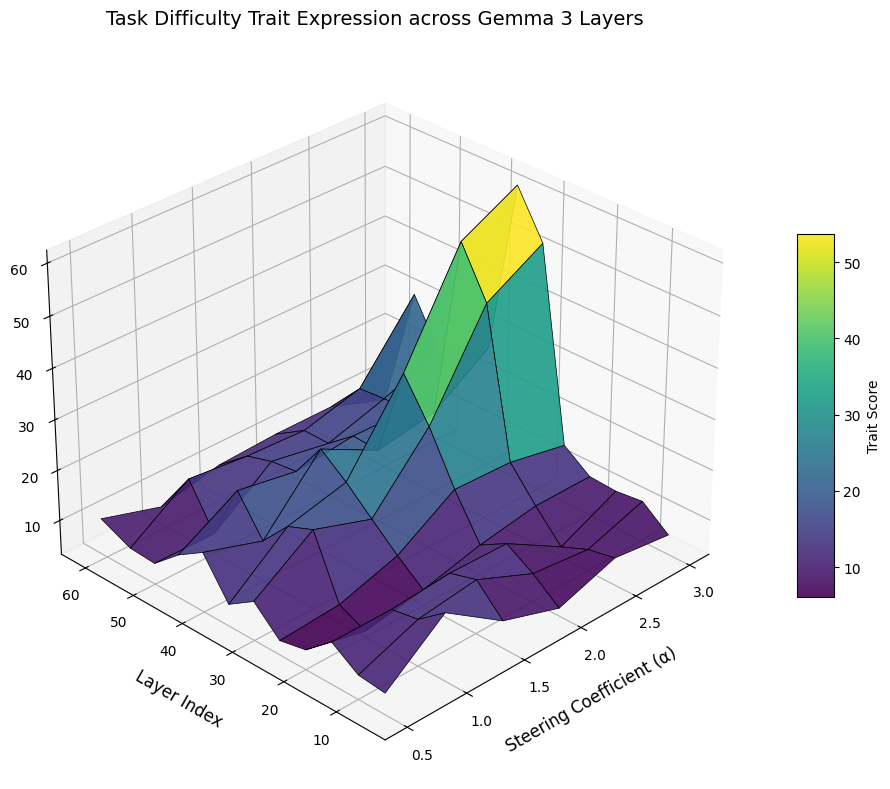

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the scored data
with open("steered_sweep_responses_scored.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Clean out any API errors or "REFUSAL" strings so we can calculate the mean
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# 2. Generate the Pivot Table Matrix
# Rows = Layers, Columns = Coefficients, Values = Mean Score
pivot_table = df.pivot_table(
    index='layer',
    columns='coeff',
    values='score',
    aggfunc='mean'
)

print("--- MEAN TASK DIFFICULTY SCORE BY LAYER AND COEFFICIENT ---")
display(pivot_table.round(2))
print("-" * 60)

# 3. Create the 3D Surface Plot
# Prepare the meshgrid for plotting
X, Y = np.meshgrid(pivot_table.columns, pivot_table.index)
Z = pivot_table.values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface using a heatmap color gradient
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9
)

# Customize the axes
ax.set_xlabel('Steering Coefficient (\u03b1)', fontsize=12, labelpad=10)
ax.set_ylabel('Layer Index', fontsize=12, labelpad=10)
ax.set_zlabel('Mean Trait Score (0-100)', fontsize=12, labelpad=10)
ax.set_title('Task Difficulty Trait Expression across Gemma 3 Layers', fontsize=14, pad=20)

# Add a color bar mapping values to colors
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Trait Score')

# Adjust the viewing angle (Elevation, Azimuth) for better visibility
ax.view_init(elev=30, azim=225)

plt.tight_layout()
plt.show()

EXTRACTED MEAN TASK DIFFICULTY SCORES (LAYER x COEFFICIENT)


coeff,0.5,1.0,1.5,2.0,2.5,3.0
layer,,,,,,
5,7.35,16.47,8.53,4.71,8.53,7.06
10,7.94,12.35,13.82,8.82,7.50,11.18
15,11.47,11.47,12.33,12.06,5.29,10.59
20,7.06,4.33,6.25,9.06,10.88,10.94
25,6.00,6.76,10.31,17.50,17.06,14.71
30,10.88,18.82,14.88,27.35,45.94,52.33
35,7.50,16.76,19.56,35.31,55.47,61.25
40,15.00,11.18,23.53,17.50,19.38,27.06
45,11.76,18.53,16.47,17.81,17.50,24.12



🎯 Peak Steered Score: 61.25 (Layer 35, α = 3.0)


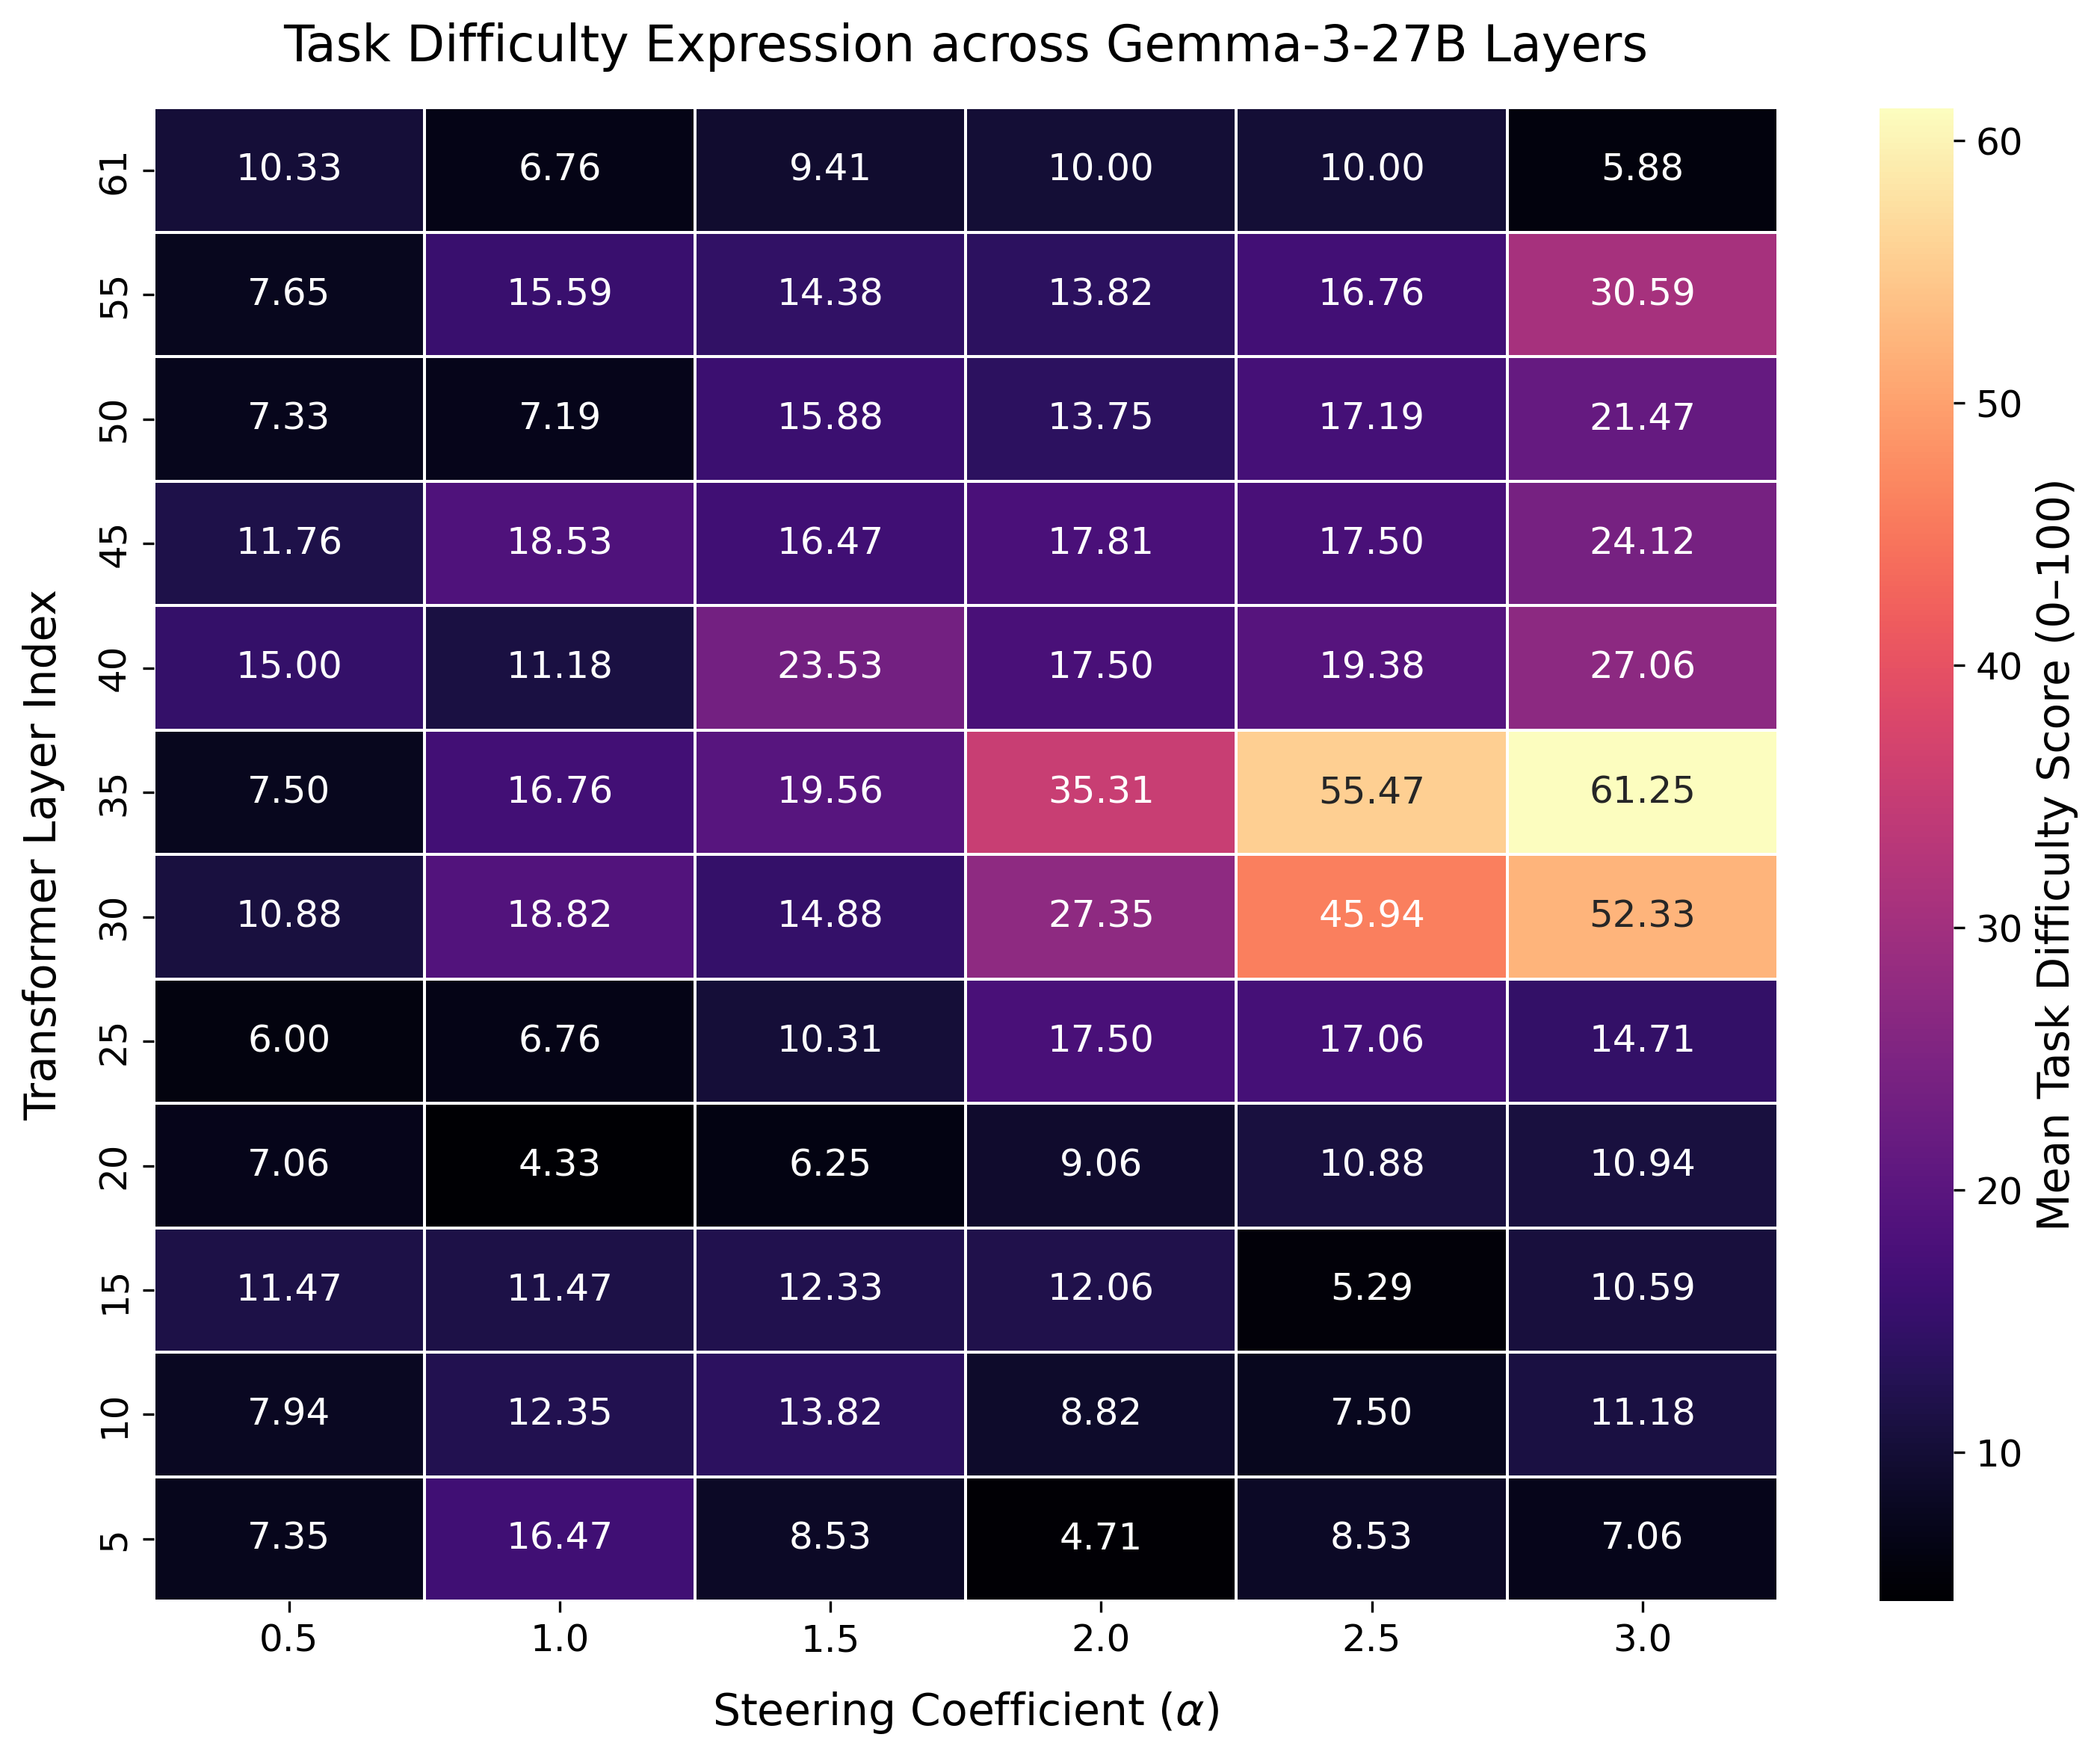

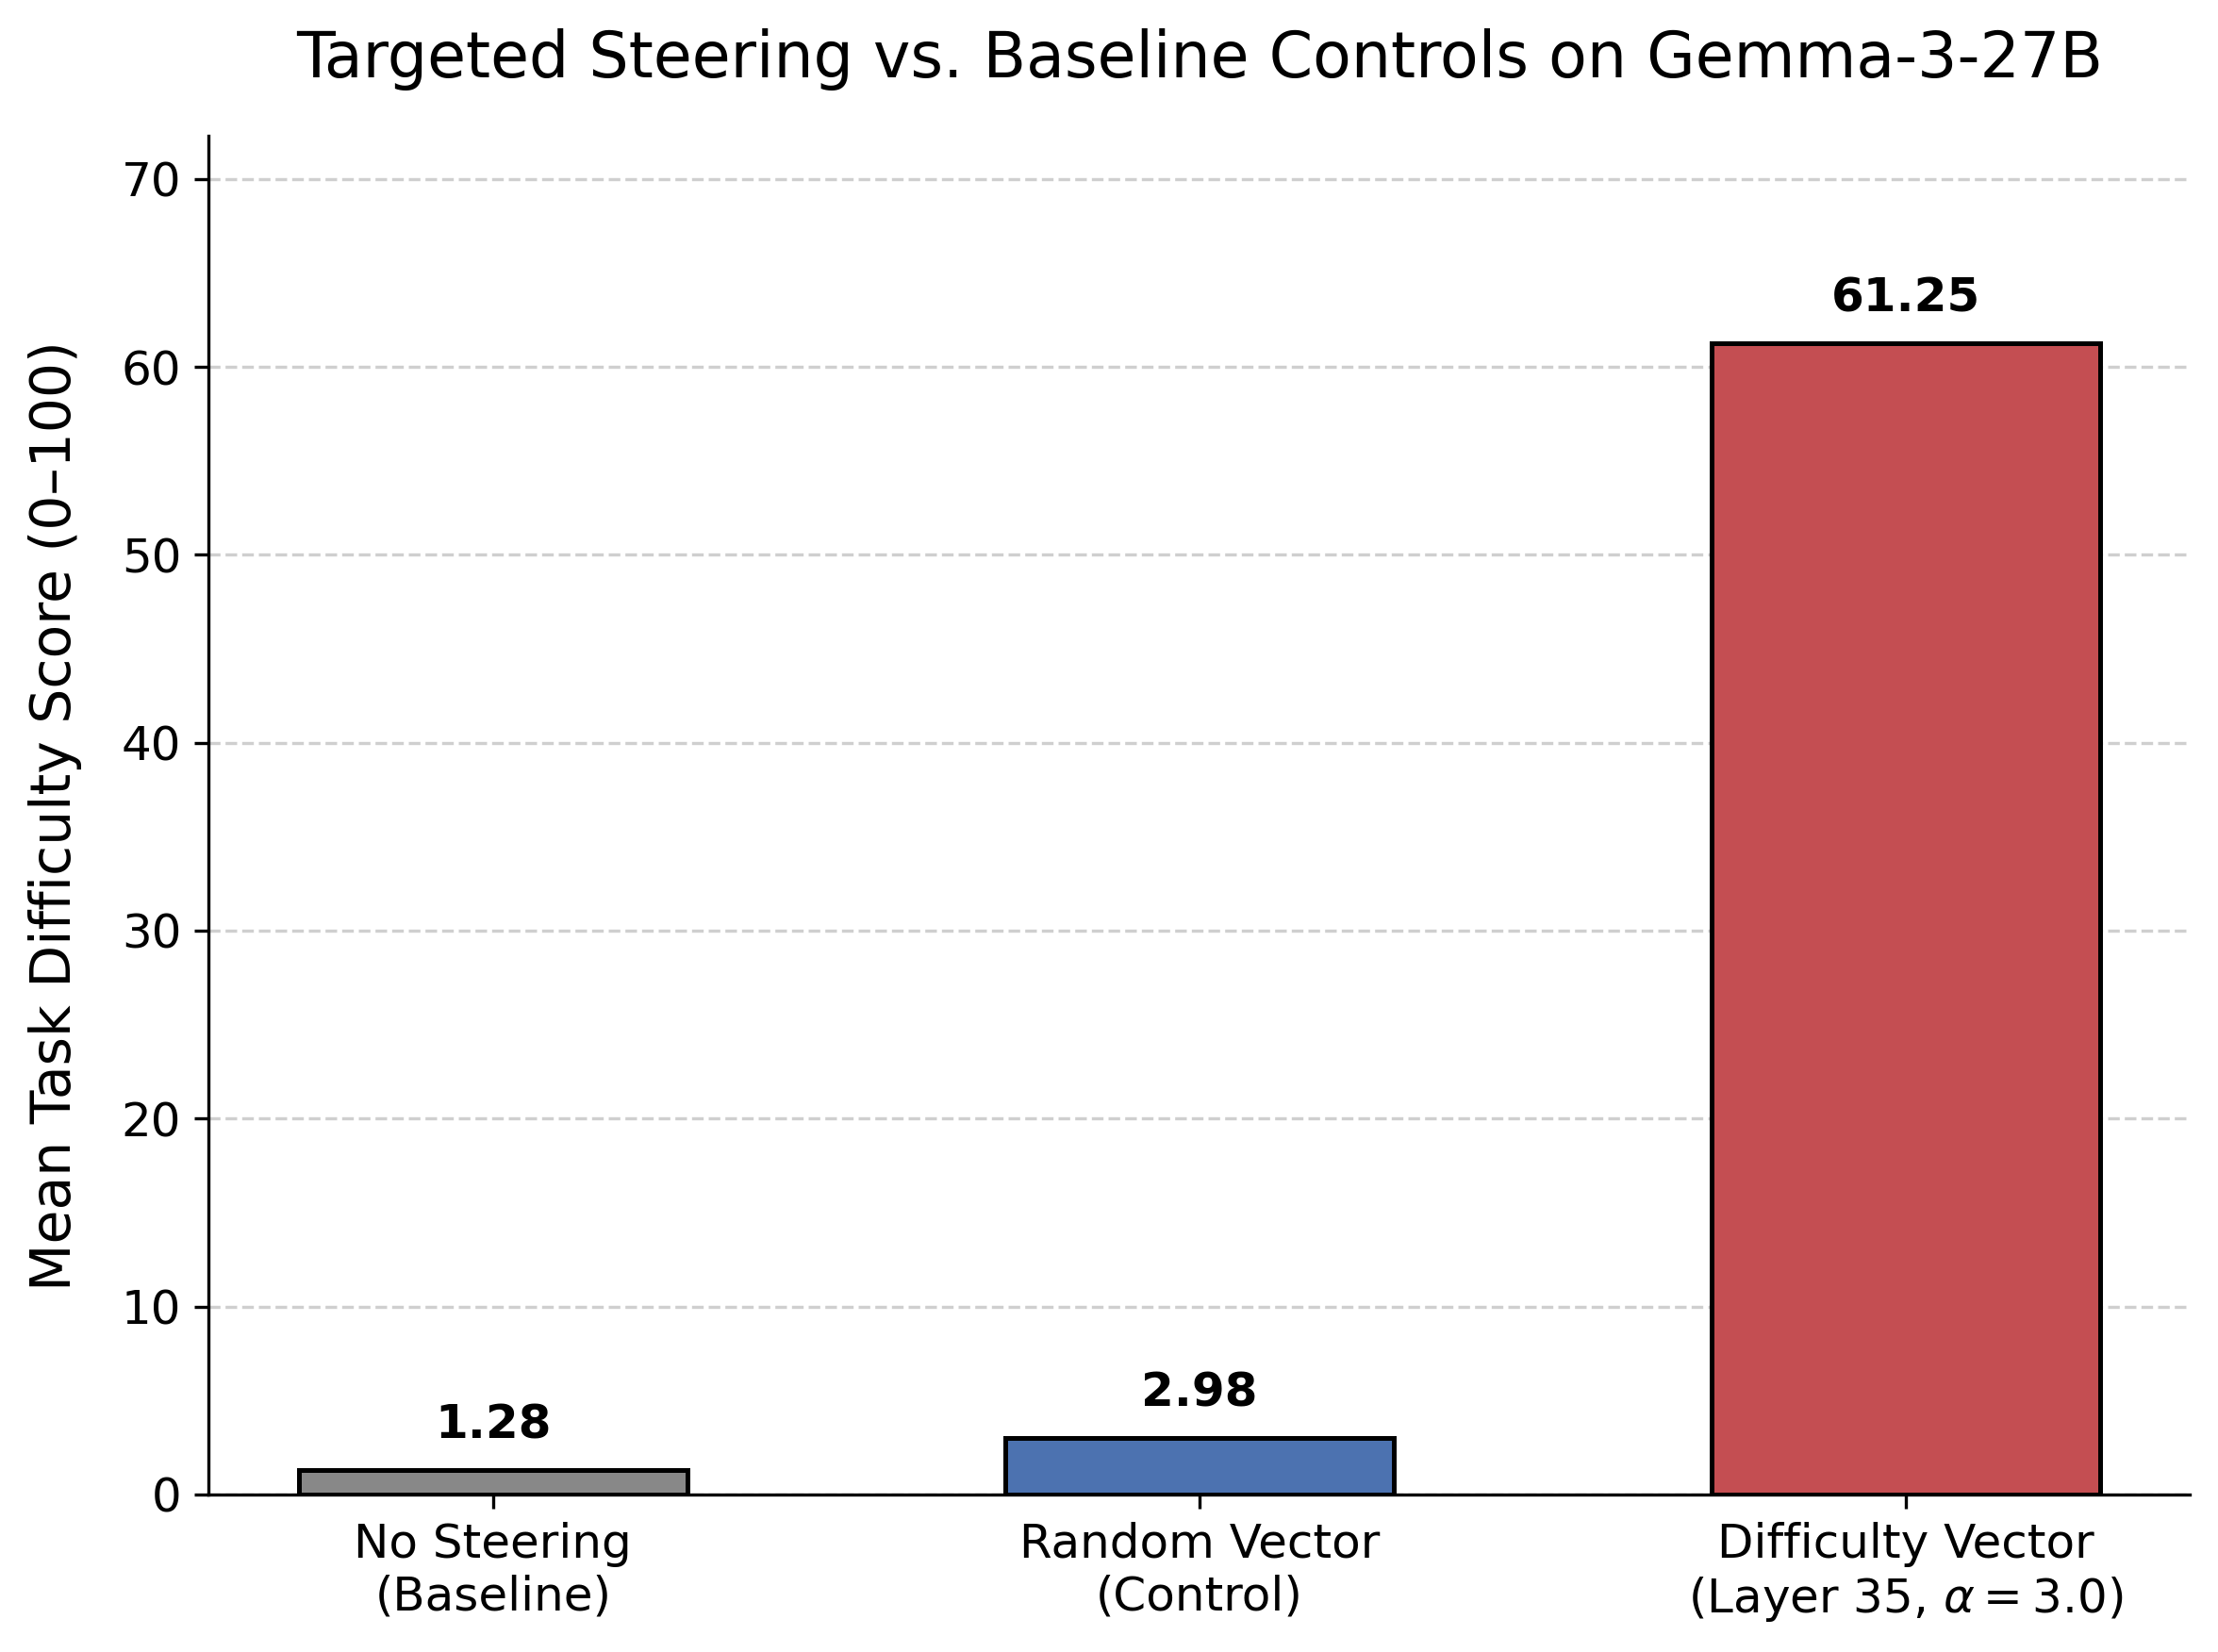

In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. REPORT STYLE SETTINGS
# ==========================================
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'font.family': 'sans-serif'
})

# ==========================================
# 2. LOAD & EXTRACT MEANS FROM JSON
# ==========================================
with open("steered_sweep_responses_scored.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Coerce any API errors or 'REFUSAL' strings into NaN so they don't break arithmetic
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# Extract the mean score matrix
pivot_table = df.pivot_table(
    index='layer',
    columns='coeff',
    values='score',
    aggfunc='mean'
)

# Display the extracted means table in the console/notebook
print("=" * 60)
print("EXTRACTED MEAN TASK DIFFICULTY SCORES (LAYER x COEFFICIENT)")
print("=" * 60)
display(pivot_table.round(2))

# Find the peak steering score and its location
peak_steered_score = pivot_table.max().max()
best_layer = pivot_table.stack().idxmax()[0]
best_coeff = pivot_table.stack().idxmax()[1]

print(f"\n🎯 Peak Steered Score: {peak_steered_score:.2f} (Layer {best_layer}, \u03b1 = {best_coeff})")

# ==========================================
# 3. HEATMAP OF EXTRACTED MEANS
# ==========================================
fig_heat, ax_heat = plt.subplots(figsize=(10, 8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="magma",
    cbar_kws={'label': 'Mean Task Difficulty Score (0–100)'},
    ax=ax_heat,
    linewidths=0.5,
    linecolor='white'
)

ax_heat.set_xlabel(r'Steering Coefficient ($\alpha$)', labelpad=10)
ax_heat.set_ylabel('Transformer Layer Index', labelpad=10)
ax_heat.set_title('Task Difficulty Expression across Gemma-3-27B Layers', pad=15)
ax_heat.invert_yaxis()  # Early layers at bottom/standard orientation

plt.tight_layout()
fig_heat.savefig("heatmap_task_difficulty_sweep.pdf", format='pdf', bbox_inches='tight')
fig_heat.savefig("heatmap_task_difficulty_sweep.png", format='png', bbox_inches='tight')
plt.show()

# ==========================================
# 4. BASELINE COMPARISON BAR CHART
# ==========================================
score_no_steering = 1.28      # Peak of Baseline (No Steering)
score_random_steer = 2.98     # Peak of Baseline (Random Steering)

labels = [
    'No Steering\n(Baseline)',
    'Random Vector\n(Control)',
    f'Difficulty Vector\n(Layer {best_layer}, $\\alpha={best_coeff}$)'
]
values = [score_no_steering, score_random_steer, peak_steered_score]
colors = ['#888888', '#4c72b0', '#c44e52']  # Gray, Blue, Red

fig_bar, ax_bar = plt.subplots(figsize=(8, 6))
bars = ax_bar.bar(labels, values, color=colors, width=0.55, edgecolor='black', linewidth=1.2)

# Annotate values above bars
for bar in bars:
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.2,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax_bar.set_ylabel('Mean Task Difficulty Score (0–100)', labelpad=10)
ax_bar.set_title('Targeted Steering vs. Baseline Controls on Gemma-3-27B', pad=15)
ax_bar.set_ylim(0, max(values) * 1.18)
ax_bar.yaxis.grid(True, linestyle='--', alpha=0.6)
ax_bar.set_axisbelow(True)

# Clean minimalist spines
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

plt.tight_layout()
fig_bar.savefig("baseline_comparison_bar.pdf", format='pdf', bbox_inches='tight')
fig_bar.savefig("baseline_comparison_bar.png", format='png', bbox_inches='tight')
plt.show()